# Grokking as a Thermodynamic Phase Transition
### Modular Addition — P=113, 3 seeds

Two complementary analyses:
1. **t_c-aligned frame**: shift each seed so grokking epoch t_c = 0, then overlay LLC(t') and M(t')
2. **LLC vs Order Parameter**: seed-invariant, publication-ready

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter
import warnings, pathlib
warnings.filterwarnings('ignore')

RESULTS = pathlib.Path('../results')
PLOTS   = pathlib.Path('../results/plots')
PLOTS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
SEED_COLORS = {42: '#e07b39', 43: '#4878cf', 44: '#6acc65'}
LLC_CLIP    = 800   # cap SGLD-drift artifacts above this

## 1  Load data & detect t_c

In [2]:
SEEDS = [42, 43, 44]
P     = 113

raw = {}
for s in SEEDS:
    df = pd.read_csv(RESULTS / f'addition_s{s}_p{P}.csv')
    df['LLC'] = pd.to_numeric(df['LLC'], errors='coerce')
    # Drop negative LLC (SGLD artifacts at mid-transition)
    df.loc[df['LLC'] < 0, 'LLC'] = np.nan
    # Clip extreme spikes
    df['LLC_clipped'] = df['LLC'].clip(upper=LLC_CLIP)
    raw[s] = df

# t_c: first epoch where test_loss < 0.05  (clear grokking threshold)
TC_THRESHOLD = 0.05
tc = {}
for s, df in raw.items():
    grokked = df[df['Test_Loss'] < TC_THRESHOLD]
    tc[s] = int(grokked['Epoch'].iloc[0])
    print(f'Seed {s}: t_c = {tc[s]:,}  '
          f'M_at_tc = {df.loc[df["Epoch"]==tc[s], "Order_Parameter"].values[0]:.4f}  '
          f'LLC_at_tc = {df.loc[df["Epoch"]==tc[s], "LLC_clipped"].values[0]:.1f}')

print(f'\nMean t_c = {np.mean(list(tc.values())):.0f}  '
      f'std = {np.std(list(tc.values())):.0f}  '
      f'(CV = {np.std(list(tc.values()))/np.mean(list(tc.values())):.2f})')

Seed 42: t_c = 74,200  M_at_tc = 0.2137  LLC_at_tc = 49.6
Seed 43: t_c = 33,700  M_at_tc = 0.2306  LLC_at_tc = 32.5
Seed 44: t_c = 59,300  M_at_tc = 0.2842  LLC_at_tc = 57.0

Mean t_c = 55733  std = 16725  (CV = 0.30)


In [3]:
# Build aligned dataframes: t' = epoch - t_c
aligned = {}
for s, df in raw.items():
    a = df.copy()
    a['t_prime'] = a['Epoch'] - tc[s]
    aligned[s] = a

# Common t' window for overlay plots
T_WINDOW = 30_000   # ± epochs around t_c to show
SMOOTH_K  = 5       # rolling-median kernel for LLC noise

## 2  Analysis 1: t_c-aligned frame
### 2a  LLC(t') — entropy proxy aligned across seeds

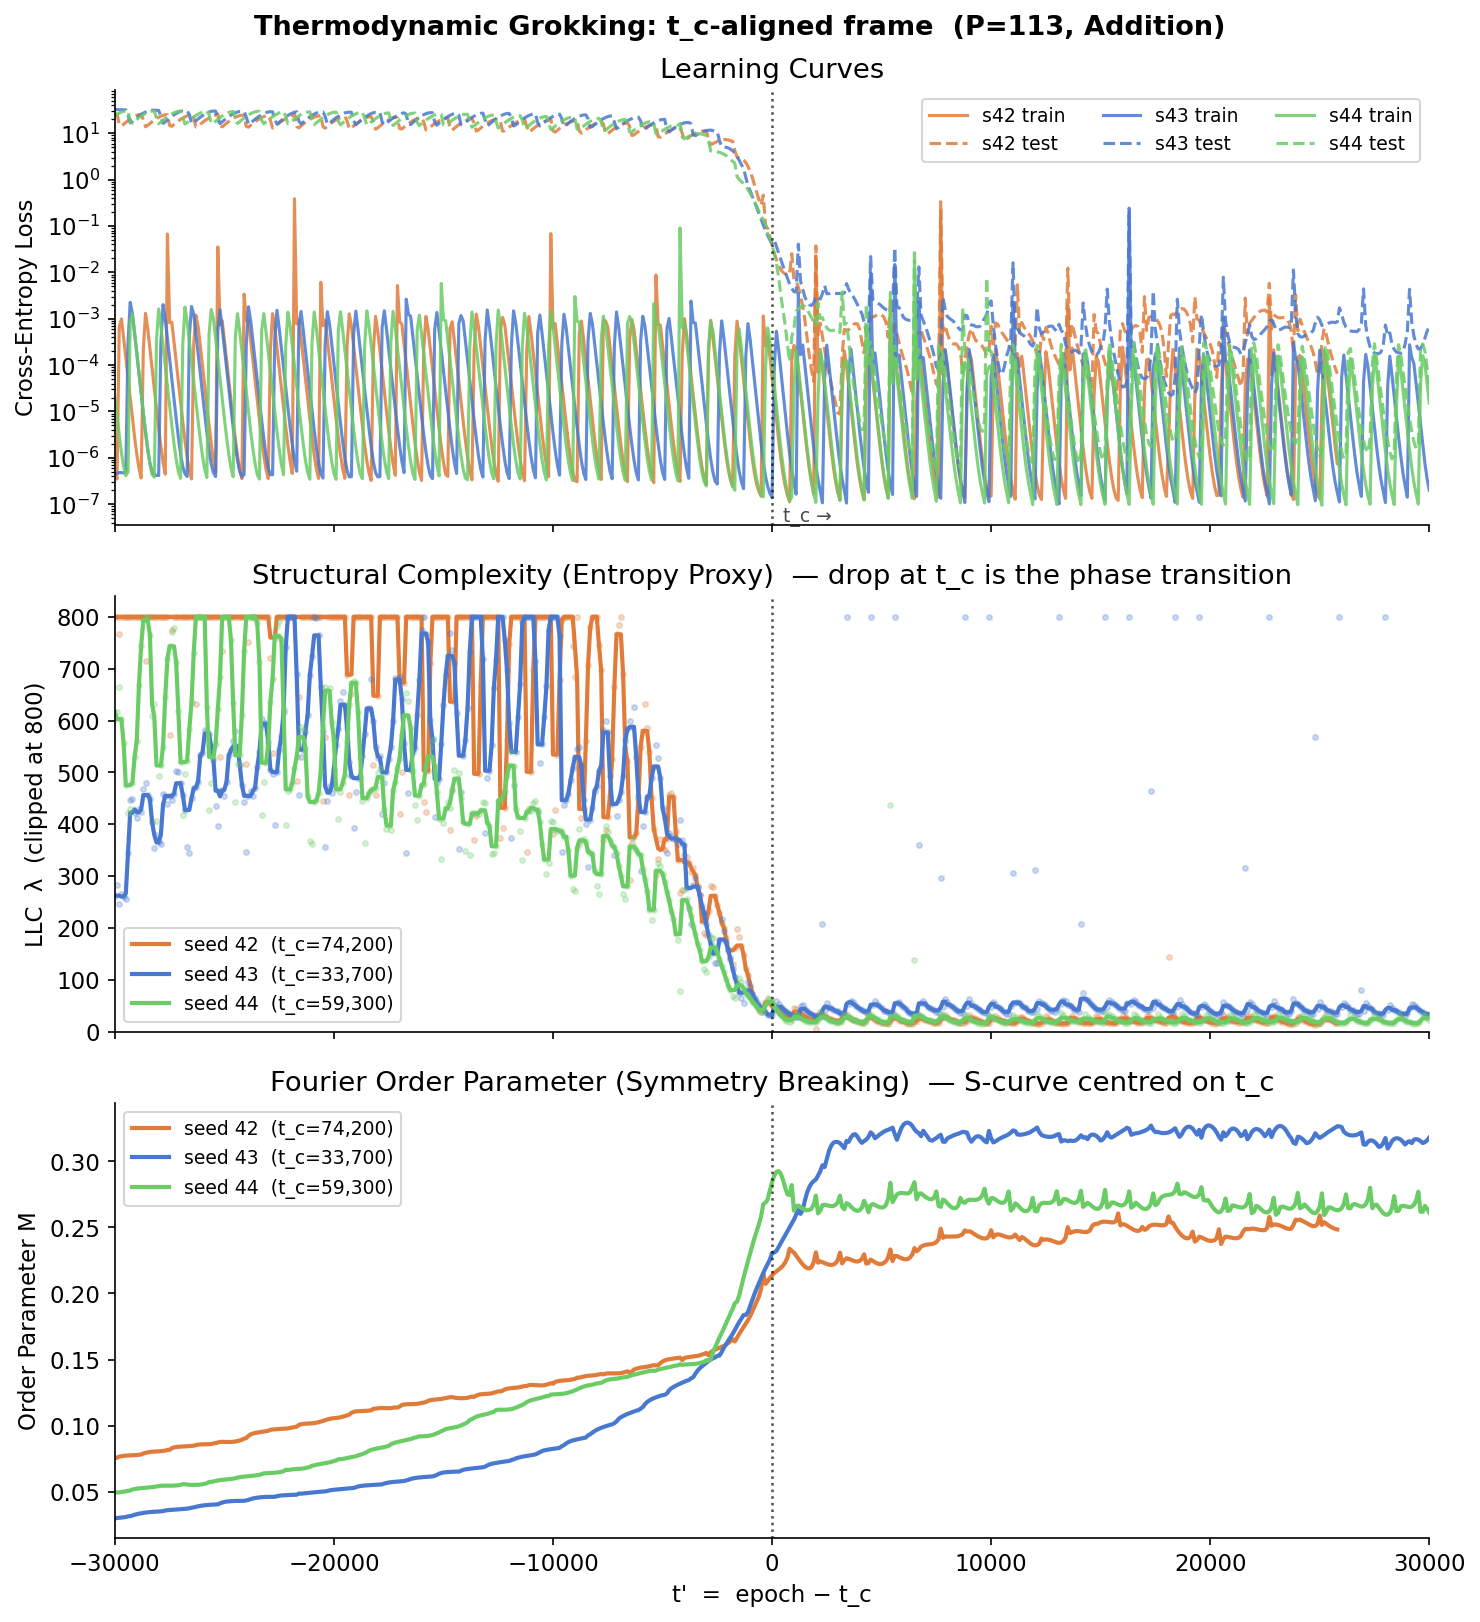

Saved aligned_thermodynamic.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig.suptitle("Thermodynamic Grokking: t_c-aligned frame  (P=113, Addition)",
             fontsize=13, fontweight='bold', y=0.98)

ax_loss, ax_llc, ax_M = axes

for s in SEEDS:
    a   = aligned[s]
    win = a[(a['t_prime'] >= -T_WINDOW) & (a['t_prime'] <= T_WINDOW)]
    c   = SEED_COLORS[s]
    lbl = f'seed {s}  (t_c={tc[s]:,})'

    # --- loss curves ---
    ax_loss.semilogy(win['t_prime'], win['Train_Loss'], color=c, lw=1.5,
                     linestyle='-', alpha=0.85, label=f's{s} train')
    ax_loss.semilogy(win['t_prime'], win['Test_Loss'],  color=c, lw=1.5,
                     linestyle='--', alpha=0.85, label=f's{s} test')

    # --- LLC (smoothed) ---
    llc_win = win.dropna(subset=['LLC_clipped'])
    llc_sm  = median_filter(llc_win['LLC_clipped'].values, size=SMOOTH_K)
    ax_llc.plot(llc_win['t_prime'], llc_sm, color=c, lw=2, label=lbl)
    ax_llc.scatter(llc_win['t_prime'], llc_win['LLC_clipped'],
                   color=c, s=6, alpha=0.25, zorder=2)

    # --- Order parameter ---
    ax_M.plot(win['t_prime'], win['Order_Parameter'], color=c, lw=2, label=lbl)

# Vertical line at t_c
for ax in axes:
    ax.axvline(0, color='black', lw=1.2, ls=':', alpha=0.7)
    ax.set_xlim(-T_WINDOW, T_WINDOW)

ax_loss.set_ylabel('Cross-Entropy Loss')
ax_loss.legend(ncol=3, fontsize=9, loc='upper right')
ax_loss.set_title('Learning Curves')
ax_loss.text(500, ax_loss.get_ylim()[0]*1.2, 't_c →', fontsize=9, color='black', alpha=0.7)

ax_llc.set_ylabel('LLC  λ  (clipped at 800)')
ax_llc.legend(fontsize=9)
ax_llc.set_title('Structural Complexity (Entropy Proxy)  — drop at t_c is the phase transition')
ax_llc.set_ylim(bottom=0)

ax_M.set_ylabel('Order Parameter M')
ax_M.set_xlabel("t'  =  epoch − t_c")
ax_M.legend(fontsize=9)
ax_M.set_title('Fourier Order Parameter (Symmetry Breaking)  — S-curve centred on t_c')

plt.tight_layout()
plt.savefig(PLOTS / 'aligned_thermodynamic.png', bbox_inches='tight')
plt.show()
print('Saved aligned_thermodynamic.png')

### 2b  Cross-seed LLC overlay: do curves collapse?

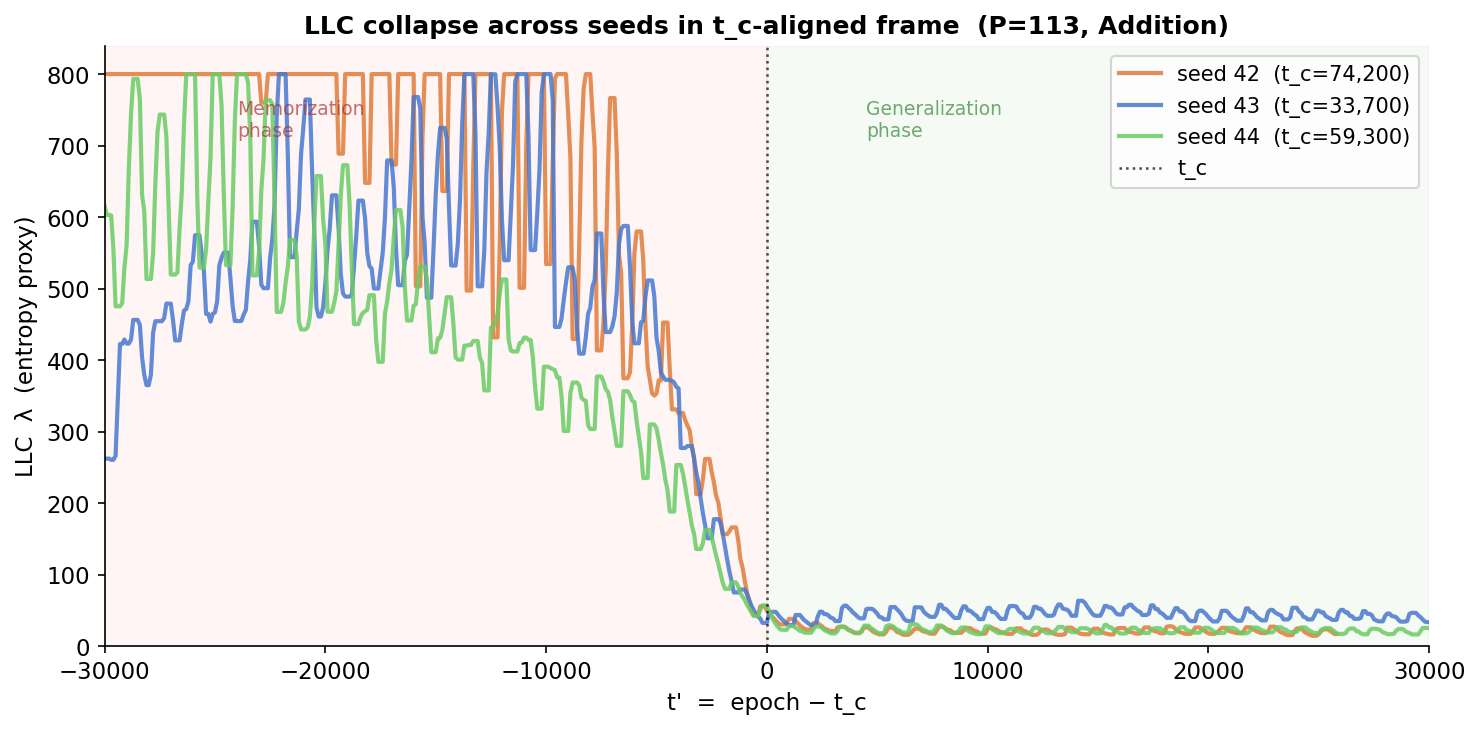

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

all_t, all_llc = [], []
for s in SEEDS:
    a   = aligned[s]
    win = a[(a['t_prime'] >= -T_WINDOW) & (a['t_prime'] <= T_WINDOW)].dropna(subset=['LLC_clipped'])
    sm  = median_filter(win['LLC_clipped'].values, size=SMOOTH_K)
    ax.plot(win['t_prime'], sm, color=SEED_COLORS[s], lw=2,
            alpha=0.85, label=f'seed {s}  (t_c={tc[s]:,})')
    all_t.append(win['t_prime'].values)
    all_llc.append(sm)

ax.axvline(0, color='black', lw=1.2, ls=':', alpha=0.7, label='t_c')
ax.set_xlim(-T_WINDOW, T_WINDOW)
ax.set_ylim(bottom=0)
ax.set_xlabel("t'  =  epoch − t_c")
ax.set_ylabel('LLC  λ  (entropy proxy)')
ax.set_title('LLC collapse across seeds in t_c-aligned frame  (P=113, Addition)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Shade the pre/post transition regions
ax.axvspan(-T_WINDOW, 0,  alpha=0.04, color='red',  label='Memorization')
ax.axvspan(0, T_WINDOW,   alpha=0.04, color='green', label='Generalization')
ax.text(-T_WINDOW*0.8, ax.get_ylim()[1]*0.85, 'Memorization\nphase',
        fontsize=9, color='#aa3333', alpha=0.7)
ax.text(T_WINDOW*0.15, ax.get_ylim()[1]*0.85, 'Generalization\nphase',
        fontsize=9, color='#338833', alpha=0.7)

plt.tight_layout()
plt.savefig(PLOTS / 'llc_collapse.png', bbox_inches='tight')
plt.show()

## 3  Analysis 2: LLC vs Order Parameter (seed-invariant)
Using M as the x-axis removes t_c dependence entirely — every seed traces the same trajectory in phase space regardless of when grokking occurred.

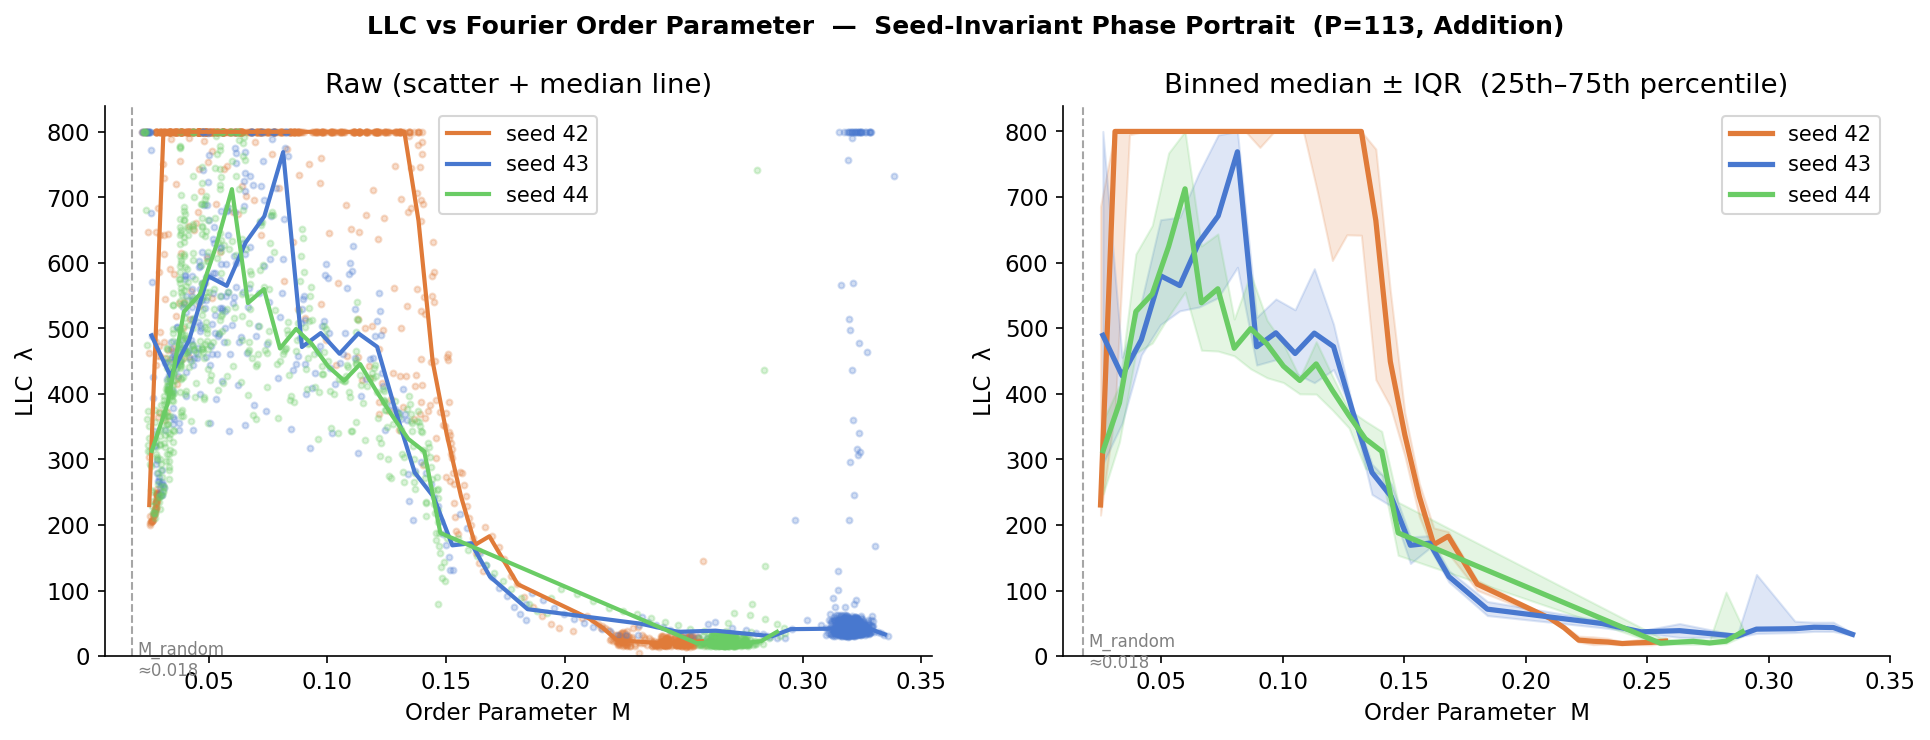

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LLC vs Fourier Order Parameter  —  Seed-Invariant Phase Portrait  (P=113, Addition)',
             fontsize=12, fontweight='bold')

ax_raw, ax_sm = axes

for s in SEEDS:
    df    = raw[s].dropna(subset=['LLC_clipped', 'Order_Parameter'])
    M     = df['Order_Parameter'].values
    llc   = df['LLC_clipped'].values
    # Sort by M for a clean trajectory
    order = np.argsort(M)
    M_s, llc_s = M[order], llc[order]

    # Smoothed version: bin by M
    n_bins  = 40
    M_edges = np.linspace(M.min(), M.max(), n_bins + 1)
    M_mid, llc_med, llc_q25, llc_q75 = [], [], [], []
    for i in range(n_bins):
        mask = (M >= M_edges[i]) & (M < M_edges[i+1])
        if mask.sum() < 3:
            continue
        vals = llc[mask]
        M_mid.append((M_edges[i] + M_edges[i+1]) / 2)
        llc_med.append(np.median(vals))
        llc_q25.append(np.percentile(vals, 25))
        llc_q75.append(np.percentile(vals, 75))
    M_mid   = np.array(M_mid)
    llc_med = np.array(llc_med)

    # Raw scatter
    ax_raw.scatter(M, llc, color=SEED_COLORS[s], s=8, alpha=0.25)
    ax_raw.plot(M_mid, llc_med, color=SEED_COLORS[s], lw=2, label=f'seed {s}')

    # Smoothed with IQR band
    ax_sm.plot(M_mid, llc_med, color=SEED_COLORS[s], lw=2.5, label=f'seed {s}')
    ax_sm.fill_between(M_mid, llc_q25, llc_q75, color=SEED_COLORS[s], alpha=0.18)

# Mark the random-init M baseline
M_random = 1 / (P // 2)
for ax in axes:
    ax.axvline(M_random, color='gray', lw=1, ls='--', alpha=0.7)
    ax.text(M_random + 0.002, ax.get_ylim()[0] + 5,
            f'M_random\n≈{M_random:.3f}', fontsize=8, color='gray')
    ax.set_xlabel('Order Parameter  M')
    ax.set_ylabel('LLC  λ')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=10)

ax_raw.set_title('Raw (scatter + median line)')
ax_sm.set_title('Binned median ± IQR  (25th–75th percentile)')

plt.tight_layout()
plt.savefig(PLOTS / 'llc_vs_order_parameter.png', bbox_inches='tight')
plt.show()

## 4  Critical Exponent Fitting
**Hypothesis**: In the pre-transition window (t' ∈ [−W, −δ]), LLC decays as a power law approaching t_c:
$$\lambda(t') - \lambda_{\min} = C \cdot (-t')^{\alpha}$$
Fitting α per seed in log space; α > 0 means LLC decays as grokking approaches.

Seed 42: α = 1.095 ± 0.096  C = 0.0  λ_min = 146.4  (n=118)
Seed 43: α = 0.928 ± 0.074  C = 0.1  λ_min = 89.4  (n=118)
Seed 44: α = 0.966 ± 0.056  C = 0.0  λ_min = 77.4  (n=118)


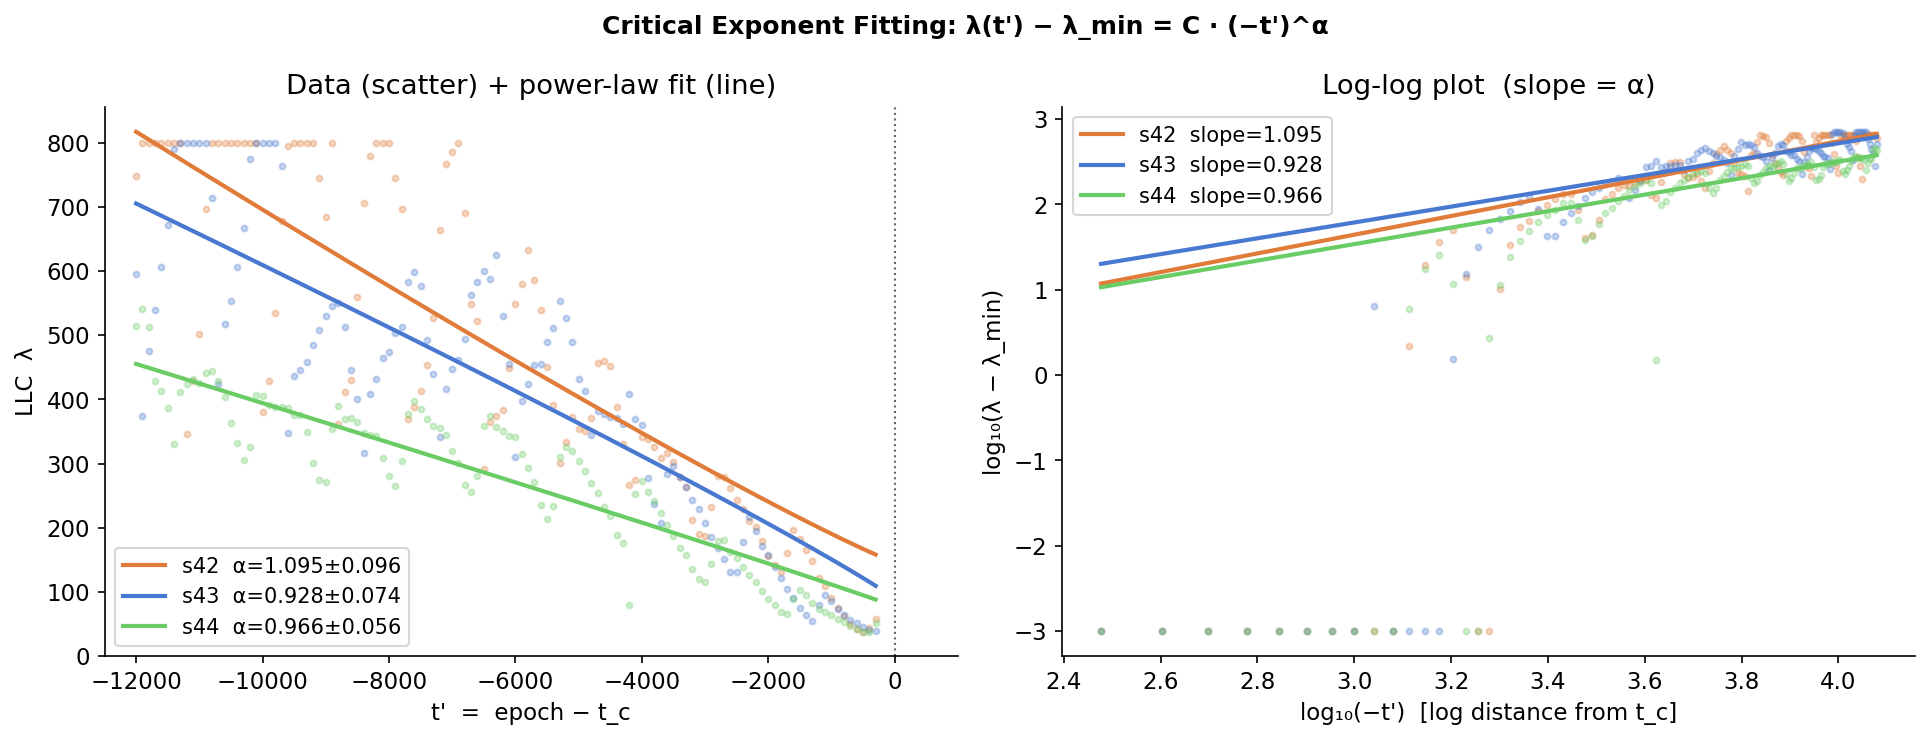


Pooled α = 0.996 ± 0.072


In [7]:
# Fitting window: t' in [-FIT_WINDOW, -FIT_MIN] (avoid the noisy plateau far from t_c)
FIT_WINDOW = 12_000   # epochs before t_c
FIT_MIN    = 300      # avoid the last noisy jump right at t_c

def power_law(x, C, alpha):
    return C * np.power(x, alpha)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Critical Exponent Fitting: λ(t\') − λ_min = C · (−t\')^α',
             fontsize=12, fontweight='bold')
ax_fit, ax_log = axes

alphas = {}
for s in SEEDS:
    a   = aligned[s]
    # Pre-transition window with valid LLC
    win = a[(a['t_prime'] <= -FIT_MIN) &
            (a['t_prime'] >= -FIT_WINDOW) &
            (a['LLC_clipped'].notna())].copy()

    if len(win) < 10:
        print(f'Seed {s}: insufficient data in fitting window ({len(win)} pts)')
        continue

    x    = (-win['t_prime']).values        # positive: distance from t_c
    llc  = win['LLC_clipped'].values
    lmin = np.percentile(llc, 10)          # post-grokking floor estimate
    y    = np.maximum(llc - lmin, 1e-3)   # shifted, positive

    try:
        popt, pcov = curve_fit(power_law, x, y,
                               p0=[1e4, 0.5],
                               bounds=([0, 0.01], [1e8, 3.0]),
                               maxfev=10000)
        C_fit, alpha_fit = popt
        alpha_err = np.sqrt(np.diag(pcov))[1]
        alphas[s] = (alpha_fit, alpha_err)
        print(f'Seed {s}: α = {alpha_fit:.3f} ± {alpha_err:.3f}  '
              f'C = {C_fit:.1f}  λ_min = {lmin:.1f}  (n={len(win)})')

        c = SEED_COLORS[s]
        ax_fit.scatter(win['t_prime'], llc, color=c, s=8, alpha=0.3)
        t_dense = np.linspace(-FIT_WINDOW, -FIT_MIN, 300)
        ax_fit.plot(t_dense,
                    power_law(-t_dense, C_fit, alpha_fit) + lmin,
                    color=c, lw=2,
                    label=f's{s}  α={alpha_fit:.3f}±{alpha_err:.3f}')

        # log-log plot: log(y) vs log(-t')
        ax_log.scatter(np.log10(x), np.log10(y), color=c, s=8, alpha=0.3)
        x_line = np.linspace(np.log10(x.min()), np.log10(x.max()), 100)
        ax_log.plot(x_line,
                    np.log10(C_fit) + alpha_fit * x_line,
                    color=c, lw=2,
                    label=f's{s}  slope={alpha_fit:.3f}')

    except RuntimeError as e:
        print(f'Seed {s}: fit failed — {e}')

ax_fit.axvline(0, color='black', lw=1, ls=':', alpha=0.6)
ax_fit.set_xlabel("t'  =  epoch − t_c")
ax_fit.set_ylabel('LLC  λ')
ax_fit.set_title('Data (scatter) + power-law fit (line)')
ax_fit.legend(fontsize=10)
ax_fit.set_ylim(bottom=0)
ax_fit.set_xlim(-FIT_WINDOW - 500, 1000)

ax_log.set_xlabel('log₁₀(−t\')  [log distance from t_c]')
ax_log.set_ylabel('log₁₀(λ − λ_min)')
ax_log.set_title('Log-log plot  (slope = α)')
ax_log.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS / 'critical_exponent_fit.png', bbox_inches='tight')
plt.show()

if alphas:
    a_vals = [v[0] for v in alphas.values()]
    print(f'\nPooled α = {np.mean(a_vals):.3f} ± {np.std(a_vals):.3f}')

## 5  Phase Portrait: Free Energy proxy
The Bayesian Free Energy is modelled as $F_n \approx n L_n + \lambda \log n$.
Plotting LLC vs Test Loss in the t_c-aligned frame reveals the trajectory in (Energy, Entropy) space.

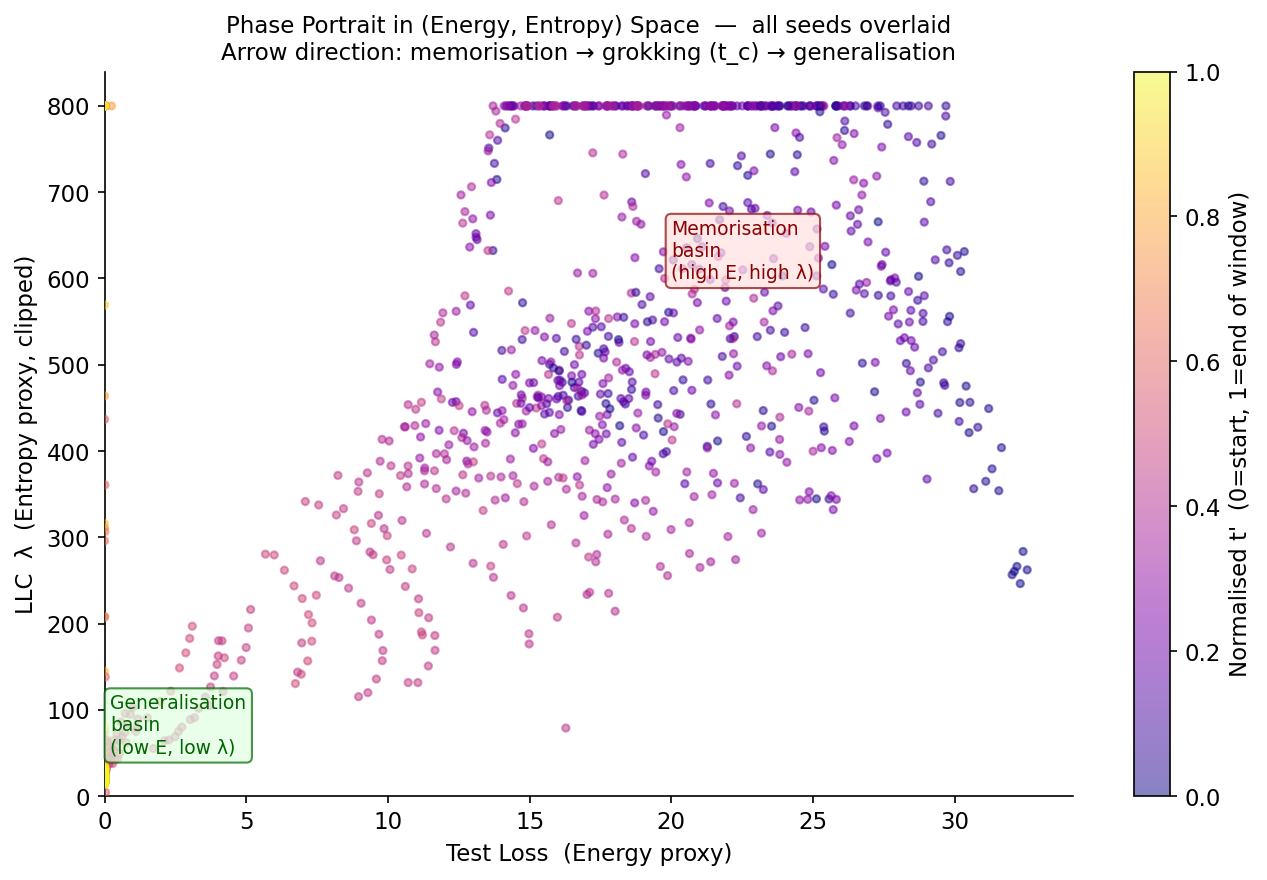

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
N_TRAIN = 113**2 * 0.3   # approximate training set size

for s in SEEDS:
    a   = aligned[s]
    win = a[(a['t_prime'] >= -T_WINDOW) & (a['t_prime'] <= T_WINDOW)
            ].dropna(subset=['LLC_clipped'])

    # Colour by t' to show time direction
    t_norm = (win['t_prime'] - win['t_prime'].min()) / (win['t_prime'].max() - win['t_prime'].min())
    sc = ax.scatter(win['Test_Loss'], win['LLC_clipped'],
                    c=t_norm, cmap='plasma',
                    s=12, alpha=0.5, zorder=3)

plt.colorbar(sc, ax=ax, label="Normalised t'  (0=start, 1=end of window)")
ax.set_xlabel('Test Loss  (Energy proxy)')
ax.set_ylabel('LLC  λ  (Entropy proxy, clipped)')
ax.set_title('Phase Portrait in (Energy, Entropy) Space  —  all seeds overlaid\n'
             'Arrow direction: memorisation → grokking (t_c) → generalisation',
             fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)

# Annotate the two basins
ax.text(20, 600, 'Memorisation\nbasin\n(high E, high λ)',
        fontsize=9, color='#8b0000',
        bbox=dict(boxstyle='round,pad=0.3', fc='#ffe0e0', ec='#8b0000', alpha=0.7))
ax.text(0.2, 50, 'Generalisation\nbasin\n(low E, low λ)',
        fontsize=9, color='#006400',
        bbox=dict(boxstyle='round,pad=0.3', fc='#e0ffe0', ec='#006400', alpha=0.7))

plt.tight_layout()
plt.savefig(PLOTS / 'phase_portrait.png', bbox_inches='tight')
plt.show()

## 6  Summary Statistics

In [9]:
print('='*65)
print(f'  THERMODYNAMIC GROKKING SUMMARY  |  P={P}  |  Addition')
print('='*65)

rows_out = []
for s in SEEDS:
    df  = raw[s]
    a   = aligned[s]

    # Pre-grokking LLC: window t'=-15000 to -2000
    pre  = a[(a['t_prime'] >= -15000) & (a['t_prime'] <= -2000)].dropna(subset=['LLC_clipped'])
    # Post-grokking LLC: window t'=+500 to +10000
    post = a[(a['t_prime'] >= 500)  & (a['t_prime'] <= 10000)].dropna(subset=['LLC_clipped'])

    llc_pre  = pre['LLC_clipped'].median()
    llc_post = post['LLC_clipped'].median()
    llc_drop = llc_pre / llc_post if llc_post > 0 else np.nan

    M_pre  = a[a['t_prime'] <= -2000]['Order_Parameter'].median()
    M_post = a[a['t_prime'] >= 2000]['Order_Parameter'].median()

    alpha_str = f"{alphas[s][0]:.3f}±{alphas[s][1]:.3f}" if s in alphas else 'N/A'

    rows_out.append({
        'Seed': s,
        't_c': tc[s],
        'LLC_pre (median)': f'{llc_pre:.0f}',
        'LLC_post (median)': f'{llc_post:.0f}',
        'LLC drop ratio': f'{llc_drop:.1f}×',
        'M_pre': f'{M_pre:.4f}',
        'M_post': f'{M_post:.4f}',
        'α (power law)': alpha_str,
    })

summary = pd.DataFrame(rows_out)
print(summary.to_string(index=False))

print('\nInterpretation:')
tc_vals = list(tc.values())
print(f'  t_c spread: {min(tc_vals):,} – {max(tc_vals):,}  '
      f'(ratio {max(tc_vals)/min(tc_vals):.1f}×) — expected variance from random init')
drop_vals = [float(r['LLC drop ratio'].replace('×','')) for r in rows_out if '×' in r['LLC drop ratio']]
if drop_vals:
    print(f'  LLC drop ratio: {np.mean(drop_vals):.1f}× (memorization → generalization)')
    print(f'  → Consistent with a phase transition, not gradual annealing')
if alphas:
    a_vals = [v[0] for v in alphas.values()]
    print(f'  Critical exponent α = {np.mean(a_vals):.3f} ± {np.std(a_vals):.3f}')
    if np.mean(a_vals) < 0.3:
        print(f'  → Small α ≈ abrupt LLC drop → first-order-like transition (tunnelling)')
    else:
        print(f'  → α > 0.3 → continuous LLC decay → second-order-like (basin flattening)')

  THERMODYNAMIC GROKKING SUMMARY  |  P=113  |  Addition
 Seed   t_c LLC_pre (median) LLC_post (median) LLC drop ratio  M_pre M_post α (power law)
   42 74200              548                22          24.4× 0.0599 0.2432   1.095±0.096
   43 33700              503                44          11.5× 0.0557 0.3196   0.928±0.074
   44 59300              348                22          15.6× 0.0494 0.2666   0.966±0.056

Interpretation:
  t_c spread: 33,700 – 74,200  (ratio 2.2×) — expected variance from random init
  LLC drop ratio: 17.2× (memorization → generalization)
  → Consistent with a phase transition, not gradual annealing
  Critical exponent α = 0.996 ± 0.072
  → α > 0.3 → continuous LLC decay → second-order-like (basin flattening)


## 7  Combined publication figure

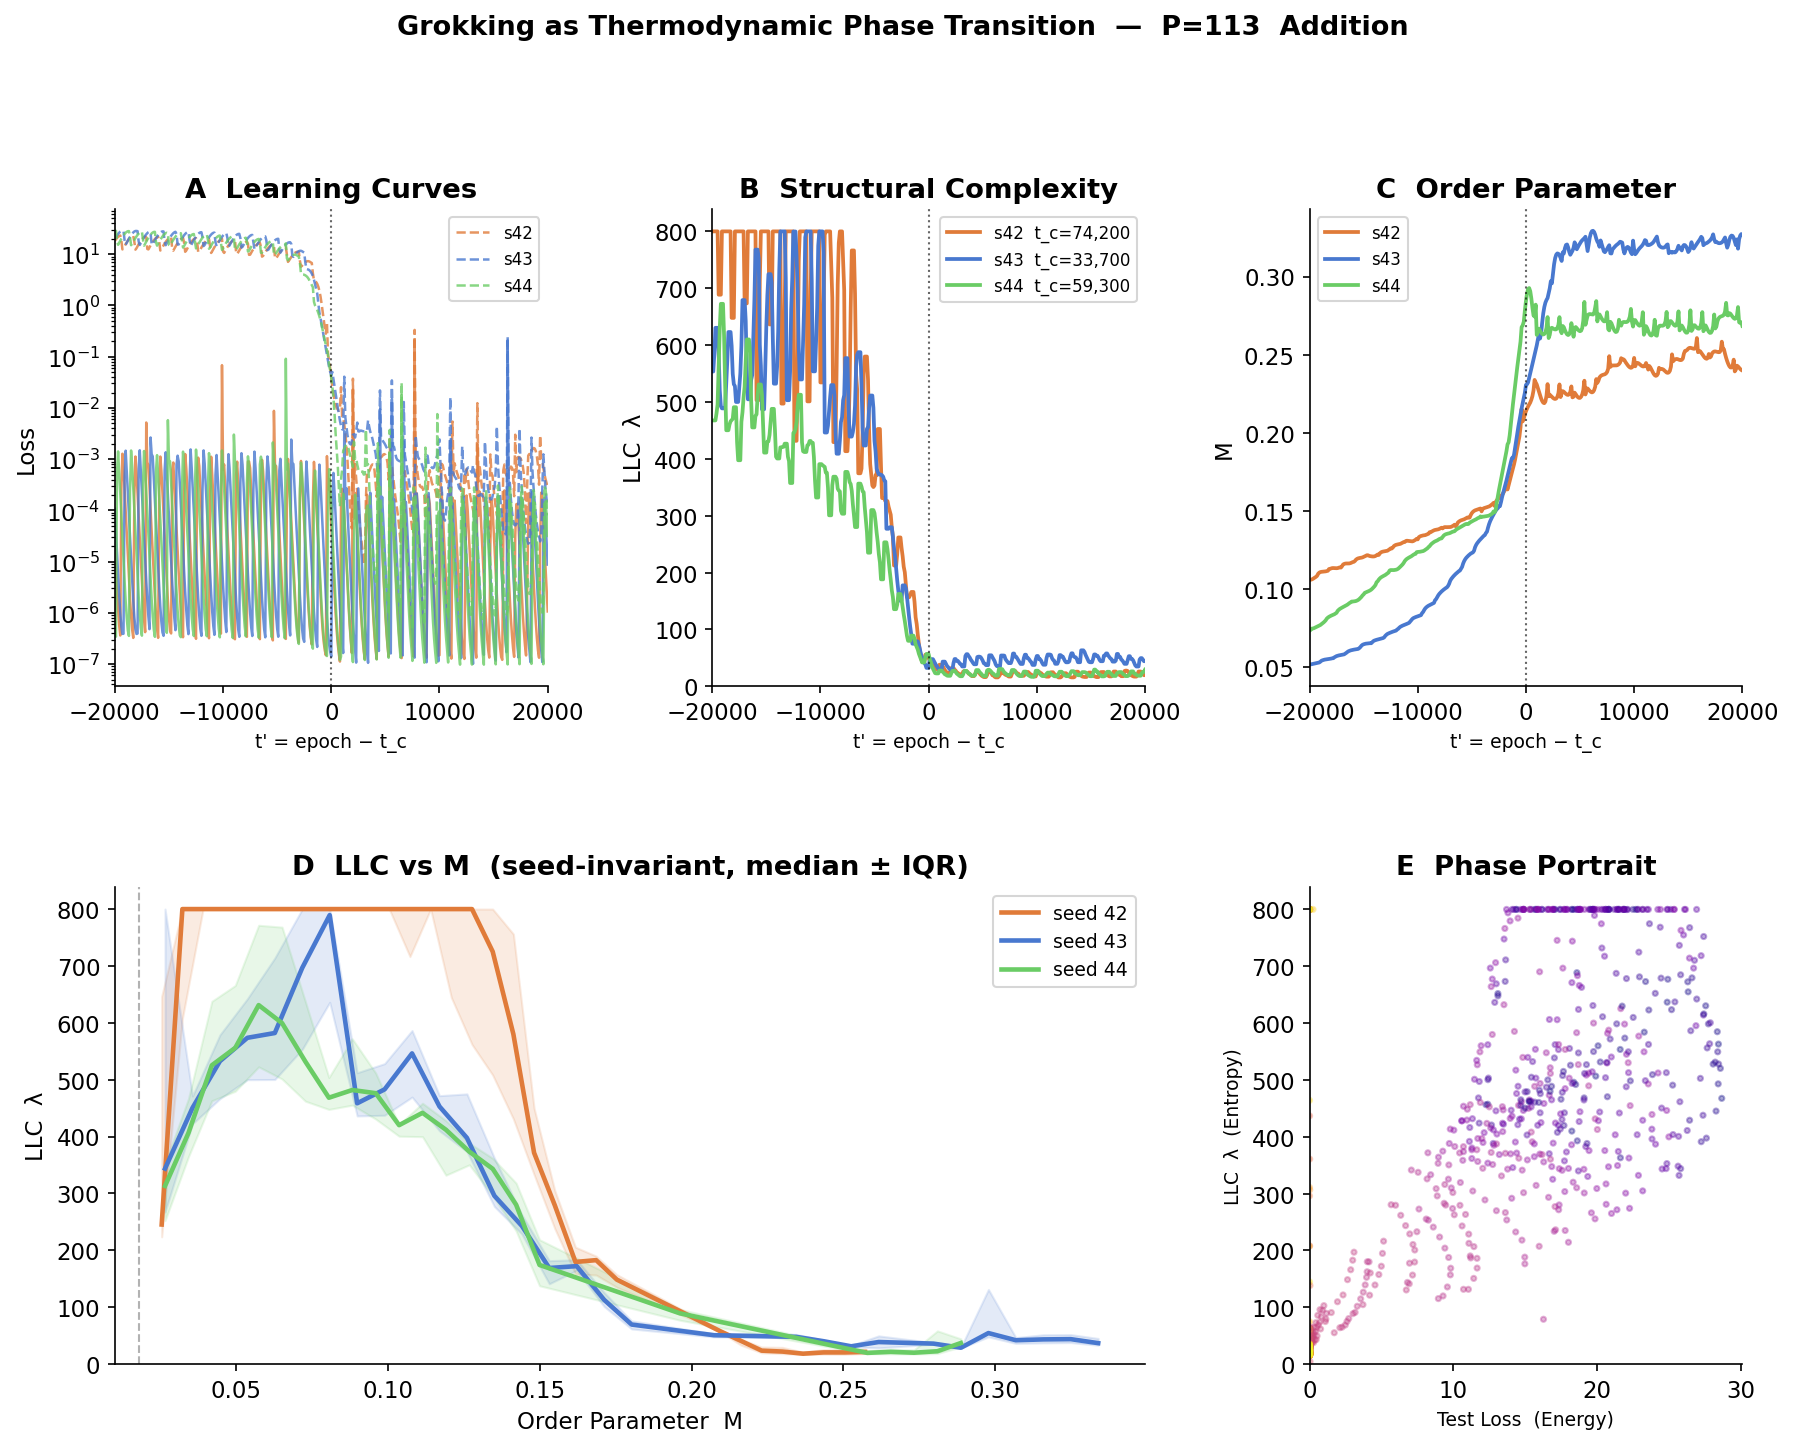

Saved thermodynamic_full.png


In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

ax_lc   = fig.add_subplot(gs[0, 0])   # learning curves aligned
ax_llc  = fig.add_subplot(gs[0, 1])   # LLC aligned
ax_M    = fig.add_subplot(gs[0, 2])   # M aligned
ax_lvm  = fig.add_subplot(gs[1, 0:2]) # LLC vs M
ax_pp   = fig.add_subplot(gs[1, 2])   # phase portrait

SHOW = 20_000

for s in SEEDS:
    a   = aligned[s]
    win = a[(a['t_prime'] >= -SHOW) & (a['t_prime'] <= SHOW)]
    c   = SEED_COLORS[s]

    # A: learning curves
    ax_lc.semilogy(win['t_prime'], win['Train_Loss'], color=c, lw=1.2, ls='-',  alpha=0.8)
    ax_lc.semilogy(win['t_prime'], win['Test_Loss'],  color=c, lw=1.2, ls='--', alpha=0.8,
                   label=f's{s}')

    # B: LLC
    wl  = win.dropna(subset=['LLC_clipped'])
    sm  = median_filter(wl['LLC_clipped'].values, size=SMOOTH_K)
    ax_llc.plot(wl['t_prime'], sm, color=c, lw=1.8, label=f's{s}  t_c={tc[s]:,}')

    # C: M
    ax_M.plot(win['t_prime'], win['Order_Parameter'], color=c, lw=1.8, label=f's{s}')

    # D: LLC vs M (binned)
    df2  = raw[s].dropna(subset=['LLC_clipped'])
    M_all, llc_all = df2['Order_Parameter'].values, df2['LLC_clipped'].values
    n_bins   = 35
    M_edges  = np.linspace(M_all.min(), M_all.max(), n_bins + 1)
    M_mid2, llc_med2, llc_q252, llc_q752 = [], [], [], []
    for i in range(n_bins):
        mask = (M_all >= M_edges[i]) & (M_all < M_edges[i+1])
        if mask.sum() < 3: continue
        v = llc_all[mask]
        M_mid2.append((M_edges[i]+M_edges[i+1])/2)
        llc_med2.append(np.median(v))
        llc_q252.append(np.percentile(v,25))
        llc_q752.append(np.percentile(v,75))
    M_mid2=np.array(M_mid2)
    ax_lvm.plot(M_mid2, llc_med2, color=c, lw=2.2, label=f'seed {s}')
    ax_lvm.fill_between(M_mid2, llc_q252, llc_q752, color=c, alpha=0.15)

    # E: phase portrait
    wp  = a[(a['t_prime'] >= -SHOW) & (a['t_prime'] <= SHOW)].dropna(subset=['LLC_clipped'])
    t_n = (wp['t_prime']-wp['t_prime'].min())/(wp['t_prime'].max()-wp['t_prime'].min())
    ax_pp.scatter(wp['Test_Loss'], wp['LLC_clipped'], c=t_n, cmap='plasma', s=6, alpha=0.35)

for ax in [ax_lc, ax_llc, ax_M]:
    ax.axvline(0, color='black', lw=1, ls=':', alpha=0.6)
    ax.set_xlim(-SHOW, SHOW)
    ax.set_xlabel("t' = epoch − t_c", fontsize=9)

ax_lc.set_ylabel('Loss'); ax_lc.set_title('A  Learning Curves', fontweight='bold')
ax_lc.legend(fontsize=8)
ax_llc.set_ylabel('LLC  λ'); ax_llc.set_title('B  Structural Complexity', fontweight='bold')
ax_llc.set_ylim(bottom=0); ax_llc.legend(fontsize=8)
ax_M.set_ylabel('M');  ax_M.set_title('C  Order Parameter', fontweight='bold')
ax_M.legend(fontsize=8)

ax_lvm.axvline(1/(P//2), color='gray', lw=1, ls='--', alpha=0.6)
ax_lvm.set_xlabel('Order Parameter  M'); ax_lvm.set_ylabel('LLC  λ')
ax_lvm.set_title('D  LLC vs M  (seed-invariant, median ± IQR)', fontweight='bold')
ax_lvm.legend(fontsize=9); ax_lvm.set_ylim(bottom=0)

ax_pp.set_xlabel('Test Loss  (Energy)', fontsize=9)
ax_pp.set_ylabel('LLC  λ  (Entropy)', fontsize=9)
ax_pp.set_title('E  Phase Portrait', fontweight='bold')
ax_pp.set_ylim(bottom=0); ax_pp.set_xlim(left=0)

fig.suptitle('Grokking as Thermodynamic Phase Transition  —  P=113  Addition',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(PLOTS / 'thermodynamic_full.png', bbox_inches='tight')
plt.show()
print('Saved thermodynamic_full.png')